# Análisis del Education-Job Mismatching

##
Predecir la probabilidad de match entre la formación académica y el campo laboral actual utilizando dos etapas:
1.  Lasso: Para selección de variables relevantes
2. XGBoost: Para predicción final

## Variable objetivo clasificada según
- `match(gpt41)`: Clasificación mediante GPT-4.1
- `match(gpt4o)`: Clasificación mediante GPT-4o  
- `Manual`: Clasificación manual

### 1. Importar librerías necesarias

In [2]:
# Instalación de XGBoost
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error
)

import xgboost as xgb
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')
print('Librerías cargadas correctamente')
print(f'XGBoost version: {xgb.__version__}')

Librerías cargadas correctamente
XGBoost version: 3.1.3


### 2. Leer el conjunto de datos y explorar la estructura

In [3]:
# Cargar datos
!gdown 1uKvx0DUvwPrKdy4K6LhCSOkV86Xbam9i
df = pd.read_excel('base_clasificadam.xlsx')

print('Dimensión de la base:', df.shape, '\n')
print(df.info())

Downloading...
From: https://drive.google.com/uc?id=1uKvx0DUvwPrKdy4K6LhCSOkV86Xbam9i
To: /content/base_clasificadam.xlsx
100% 27.2k/27.2k [00:00<00:00, 47.4MB/s]
Dimensión de la base: (221, 11) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   nombre          221 non-null    object
 1   universidad     221 non-null    object
 2   sexo            221 non-null    object
 3   carrera         221 non-null    object
 4   area            221 non-null    object
 5   egreso          221 non-null    int64 
 6   primer_trabajo  221 non-null    object
 7   empresa         217 non-null    object
 8   match(gpt41)    221 non-null    int64 
 9   match(gpt4o)    221 non-null    int64 
 10  Manual          221 non-null    int64 
dtypes: int64(4), object(7)
memory usage: 19.1+ KB
None


In [4]:
df.head(10)

,nombre,universidad,sexo,carrera,area,egreso,primer_trabajo,empresa,match(gpt41),match(gpt4o),Manual
0,Lucas Vazquez,UBA,H,Ingenieria Estructural,Ingenieria,2019,Ingeniero Civil Junior,Techint,1,1,1
1,Nicolás Vincenti,UBA,H,Ingenieria Industrial,Ingenieria,2023,Sales Strategy Associate,Salesforce,0,1,0
2,Matías Uncal,UBA,H,Ingeniería Indsutrial,Ingenieria,2016,Business Intelligence Analyst,Groupon,1,1,1
3,Joaquin Prada,UBA,H,Ingeniería en Computer Science,Ingenieria,2025,Software Developer,Mercado Libre,1,1,1
4,Federico Muradian,UBA,H,Ingenieria Industrial,Ingenieria,2015,Material Planner Analyst,SC Johnnson,1,1,1
5,Matías Scakosky,UBA,H,Ingeniero en Software,Ingenieria,2023,Software Engenieer,Pomelo,1,1,1
6,Tomás Robledo,UBA,H,Ingeniería Mecánica,Ingenieria,2024,Bioingeniería,Hospital San Martin,0,0,0
7,Carla Sobico,UBA,M,Ingenieria Civil Electrónica,Ingenieria,2025,Software Engenieer,Ekumen,1,1,0
8,Agustín Diez,UBA,H,Ingeniería Civil,Ingenieria,2019,Ingeniero Civil Sr.,Hytech,1,1,1
9,Manuel Requejo,UBA,H,Ingeniería Industrial,Ingenieria,2021,Pricing Analyst,Danone,1,1,1


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
egreso,221.0,2019.80,5.58,1992.0,2018.0,2021.0,2024.0,2026.0
match(gpt41),221.0,0.76,0.43,0.0,1.0,1.0,1.0,1.0
match(gpt4o),221.0,0.72,0.45,0.0,0.0,1.0,1.0,1.0
Manual,221.0,0.61,0.49,0.0,0.0,1.0,1.0,1.0


### 3. Chequeo de valores faltantes y limpieza de datos

In [9]:
# Seleccionar variables relevantes
variables_analisis = ['universidad', 'sexo', 'area', 'egreso',
                      'match(gpt41)', 'match(gpt4o)', 'Manual']

df_trabajo = df[variables_analisis].copy()

print('Valores faltantes por variable:')
print(df_trabajo.isnull().sum())
print('\nPorcentaje de datos faltantes:')
print((df_trabajo.isnull().sum() / len(df_trabajo) * 100).round(2))

Valores faltantes por variable:
universidad     0
sexo            0
area            0
egreso          0
match(gpt41)    0
match(gpt4o)    0
Manual          0
dtype: int64

Porcentaje de datos faltantes:
universidad     0.0
sexo            0.0
area            0.0
egreso          0.0
match(gpt41)    0.0
match(gpt4o)    0.0
Manual          0.0
dtype: float64


In [10]:
# Eliminar observaciones con valores faltantes
df_limpio = df_trabajo.dropna()

print('Nueva dimensión de la base:', df_limpio.shape)
print(f'Observaciones eliminadas: {len(df_trabajo) - len(df_limpio)} ({(len(df_trabajo) - len(df_limpio))/len(df_trabajo)*100:.1f}%)')

Nueva dimensión de la base: (221, 7)
Observaciones eliminadas: 0 (0.0%)


### 4. Exploración de variables categóricas clave

Distribución de área:
area
Ingenieria    134
Psicologia     87
Name: count, dtype: int64

Distribución porcentual:
area
Ingenieria    60.63
Psicologia    39.37
Name: proportion, dtype: float64


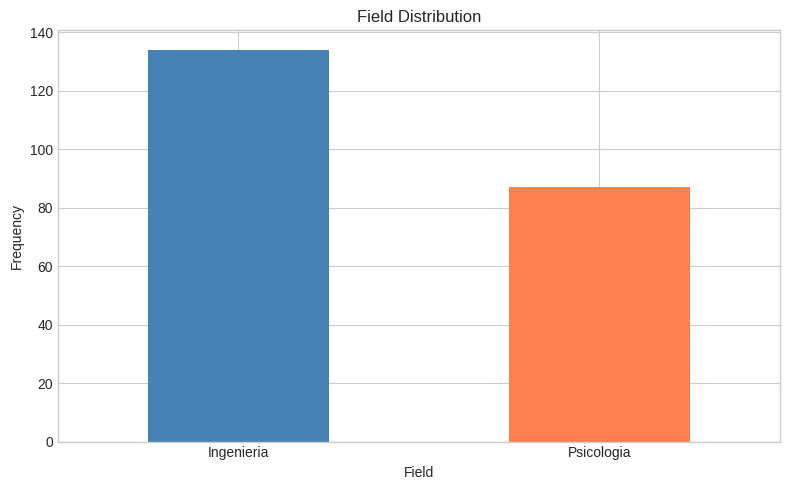

In [11]:
# Distribución de area (Ingenieria vs Psicologia)
print('Distribución de área:')
print(df_limpio['area'].value_counts())
print('\nDistribución porcentual:')
print((df_limpio['area'].value_counts(normalize=True) * 100).round(2))

# Visualización
plt.figure(figsize=(8, 5))
df_limpio['area'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Field Distribution')
plt.xlabel('Field')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 5. Preparar las X e Y que usaremos en el modelo

Creamos variables dummies para las variables categóricas utilizando `pd.get_dummies()`

In [12]:
# Variables categóricas a transformar
variables_categoricas = ['universidad', 'sexo', 'area']

# Aplicar one-hot encoding (drop_first=True para evitar colinealidad)
df_encoded = pd.get_dummies(df_limpio, columns=variables_categoricas, drop_first=True, dtype=int)

print('Dimensiones después de crear dummies:')
print(f'Observaciones: {df_encoded.shape[0]}')
print(f'Variables: {df_encoded.shape[1]}')

# Variables dummy creadas
columnas_dummy = [col for col in df_encoded.columns if any(
    col.startswith(var + '_') for var in variables_categoricas
)]

print(f'\nNúmero de variables dummy creadas: {len(columnas_dummy)}')
print(f'Primeras 18 variables dummy:')
for col in columnas_dummy[:18]:
    print(f'  - {col}')
if len(columnas_dummy) > 18:
    print(f'  ... y {len(columnas_dummy) - 10} más')

Dimensiones después de crear dummies:
Observaciones: 221
Variables: 21

Número de variables dummy creadas: 17
Primeras 18 variables dummy:
  - universidad_UCA
  - universidad_Universidad Argentina de la Empresa
  - universidad_Universidad Austral
  - universidad_Universidad Nacional de Cuyo
  - universidad_Universidad Nacional de Córdoba
  - universidad_Universidad Nacional de La Plata
  - universidad_Universidad Nacional de Rosario
  - universidad_Universidad Nacional de San Luis
  - universidad_Universidad Nacional de San Martín (UNSAM)
  - universidad_Universidad Nacional del Centro de la Provincia de Buenos Aires
  - universidad_Universidad Nacional del Litoral
  - universidad_Universidad Nacional del Sur
  - universidad_Universidad Tecnológica Nacional (UTN)
  - universidad_Universidad de Belgrano
  - universidad_Universidad de Palermo
  - sexo_M
  - area_Psicologia


In [13]:
# Definir X (variables independientes) e Y (variables dependientes)

# Excluir variables que no son predictores
columnas_excluir = ['carrera', 'match(gpt41)', 'match(gpt4o)', 'Manual','primer_trabajo']
columnas_features = [col for col in df_encoded.columns if col not in columnas_excluir]

X = df_encoded[columnas_features]

# Variables objetivo
y_gpt41 = df_encoded['match(gpt41)']
y_gpt4o = df_encoded['match(gpt4o)']
y_manual = df_encoded['Manual']

print('Estructura de datos para modelado:')
print(f'\nX (features): {X.shape}')
print(f'Número de predictores: {X.shape[1]}')
print(f'\ny_gpt41: {y_gpt41.shape[0]} obs., tasa de match: {y_gpt41.mean()*100:.1f}%')
print(f'y_gpt4o: {y_gpt4o.shape[0]} obs., tasa de match: {y_gpt4o.mean()*100:.1f}%')
print(f'y_manual: {y_manual.shape[0]} obs., tasa de match: {y_manual.mean()*100:.1f}%')

Estructura de datos para modelado:

X (features): (221, 18)
Número de predictores: 18

y_gpt41: 221 obs., tasa de match: 76.5%
y_gpt4o: 221 obs., tasa de match: 72.4%
y_manual: 221 obs., tasa de match: 61.1%


In [14]:
X.head()

,egreso,universidad_UCA,universidad_Universidad Argentina de la Empresa,universidad_Universidad Austral,universidad_Universidad Nacional de Cuyo,universidad_Universidad Nacional de Córdoba,universidad_Universidad Nacional de La Plata,universidad_Universidad Nacional de Rosario,universidad_Universidad Nacional de San Luis,universidad_Universidad Nacional de San Martín (UNSAM),universidad_Universidad Nacional del Centro de la Provincia de Buenos Aires,universidad_Universidad Nacional del Litoral,universidad_Universidad Nacional del Sur,universidad_Universidad Tecnológica Nacional (UTN),universidad_Universidad de Belgrano,universidad_Universidad de Palermo,sexo_M,area_Psicologia
0,2019,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2023,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2016,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2025,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2015,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### 7. Etapa 1: Regularización con Lasso para selección de variables

Usaremos Lasso para identificar las variables más relevantes.

In [15]:
def lasso_feature_selection(X, y, nombre_target):
    """
    Implementa selección de variables mediante Lasso con validación cruzada
    """
    print('\n' + '='*70)
    print(f'Regularización Lasso - {nombre_target}')
    print('='*70)

    # Train-test split estratificado
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f'\nEl conjunto de entrenamiento tiene {len(X_train)} observaciones.')
    print(f'El conjunto de test tiene {len(X_test)} observaciones.')

    # Normalización de features (importante para Lasso)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Matriz de valores de alpha para cross-validation
    alphas = 10**np.linspace(-2, 2, 50)

    # Lasso con validación cruzada (k=5)
    from sklearn.linear_model import LogisticRegressionCV

    lasso_cv = LogisticRegressionCV(
        penalty='l1',
        solver='liblinear',
        Cs=1/alphas,
        cv=5,
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )

    lasso_cv.fit(X_train_scaled, y_train)

    # Alpha óptimo
    alpha_optimo = 1 / lasso_cv.C_[0]
    print(f'\nAlpha óptimo: {alpha_optimo:.4f}')

    # Análisis de coeficientes
    coeficientes = pd.DataFrame({
        'Variable': X.columns,
        'Coeficiente': lasso_cv.coef_[0],
        'Coef_Abs': np.abs(lasso_cv.coef_[0])
    }).sort_values('Coef_Abs', ascending=False)

    # Identificar variables seleccionadas (coef != 0)
    umbral = 0.01
    variables_seleccionadas = coeficientes[coeficientes['Coef_Abs'] > umbral]['Variable'].tolist()
    variables_descartadas = coeficientes[coeficientes['Coef_Abs'] <= umbral]['Variable'].tolist()

    print(f'\nVariables seleccionadas: {len(variables_seleccionadas)} de {len(X.columns)}')
    print(f'Variables descartadas: {len(variables_descartadas)}')

    # Evaluación en test set
    y_pred_proba = lasso_cv.predict_proba(X_test_scaled)[:, 1]
    y_pred = lasso_cv.predict(X_test_scaled)

    auc_test = roc_auc_score(y_test, y_pred_proba)
    acc_test = accuracy_score(y_test, y_pred)
    mse_test = mean_squared_error(y_test, y_pred)

    print(f'\nRendimiento en test set:')
    print(f'  AUC: {auc_test:.4f}')
    print(f'  Accuracy: {acc_test:.4f}')
    print(f'  MSE: {mse_test:.4f}')

    return {
        'modelo': lasso_cv,
        'scaler': scaler,
        'variables_seleccionadas': variables_seleccionadas,
        'variables_descartadas': variables_descartadas,
        'coeficientes': coeficientes,
        'auc': auc_test,
        'accuracy': acc_test,
        'mse': mse_test
    }

# Ejecutar Lasso para cada target
resultados_lasso = {}

for nombre, objetivo in [('GPT-4.1', y_gpt41), ('GPT-4o', y_gpt4o), ('Manual', y_manual)]:
    resultados_lasso[nombre] = lasso_feature_selection(X, objetivo, nombre)


Regularización Lasso - GPT-4.1

El conjunto de entrenamiento tiene 176 observaciones.
El conjunto de test tiene 45 observaciones.

Alpha óptimo: 0.0100

Variables seleccionadas: 17 de 18
Variables descartadas: 1

Rendimiento en test set:
  AUC: 0.6096
  Accuracy: 0.6000
  MSE: 0.4000

Regularización Lasso - GPT-4o

El conjunto de entrenamiento tiene 176 observaciones.
El conjunto de test tiene 45 observaciones.

Alpha óptimo: 2.3300

Variables seleccionadas: 14 de 18
Variables descartadas: 4

Rendimiento en test set:
  AUC: 0.7109
  Accuracy: 0.6667
  MSE: 0.3333

Regularización Lasso - Manual

El conjunto de entrenamiento tiene 176 observaciones.
El conjunto de test tiene 45 observaciones.

Alpha óptimo: 10.4811

Variables seleccionadas: 5 de 18
Variables descartadas: 13

Rendimiento en test set:
  AUC: 0.7510
  Accuracy: 0.6222
  MSE: 0.3778


#### Visualización de coeficientes Lasso

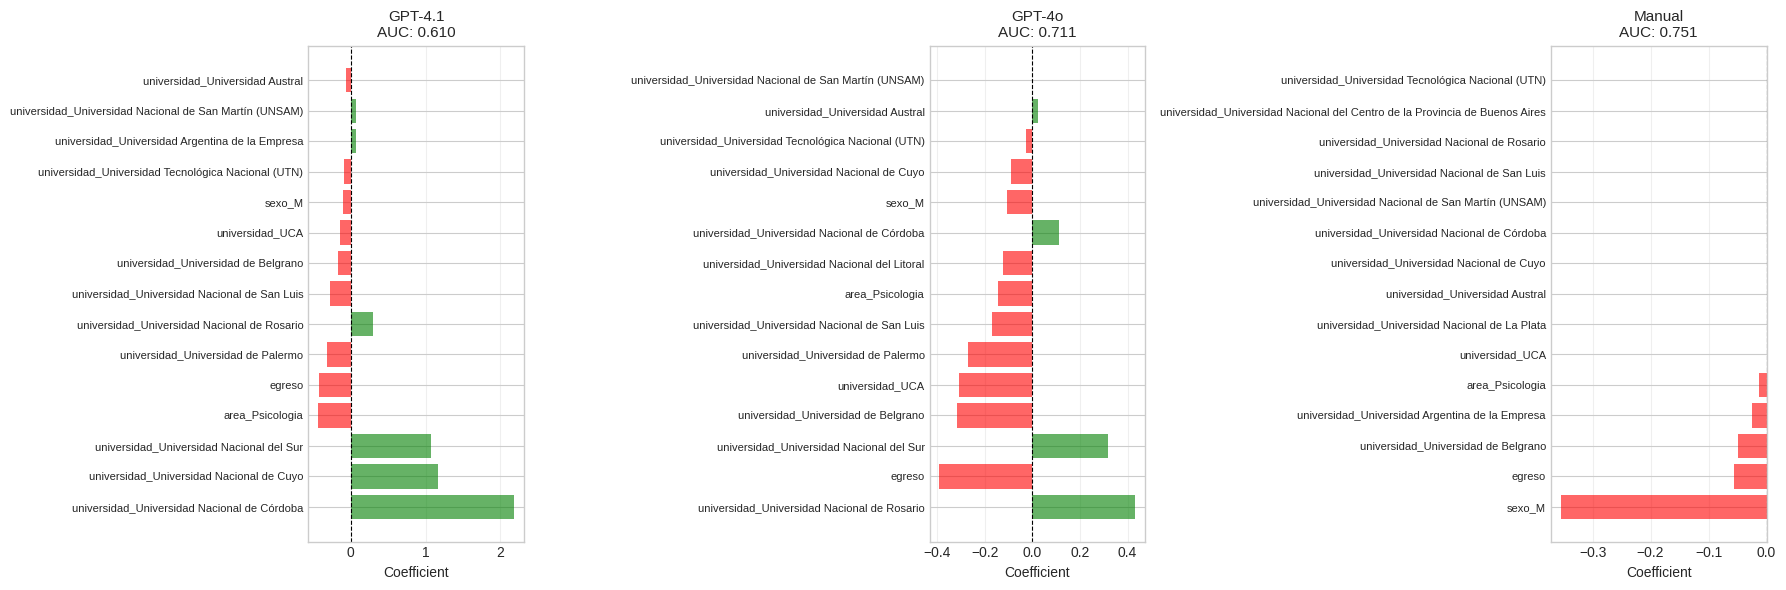

In [16]:
# Comparación de coeficientes entre targets
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, nombre in enumerate(['GPT-4.1', 'GPT-4o', 'Manual']):
    coefs = resultados_lasso[nombre]['coeficientes'].head(15)
    colores = ['red' if x < 0 else 'green' for x in coefs['Coeficiente']]

    axes[idx].barh(range(len(coefs)), coefs['Coeficiente'], color=colores, alpha=0.6)
    axes[idx].set_yticks(range(len(coefs)))
    axes[idx].set_yticklabels(coefs['Variable'], fontsize=8)
    axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    axes[idx].set_title(f'{nombre}\nAUC: {resultados_lasso[nombre]["auc"]:.3f}', fontsize=11)
    axes[idx].set_xlabel('Coefficient')
    axes[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

#### Resumen de selección de variables

In [17]:
print('='*70)
print('Resumen de selección de variables por Lasso')
print('='*70)

for nombre in ['GPT-4.1', 'GPT-4o', 'Manual']:
    n_selec = len(resultados_lasso[nombre]['variables_seleccionadas'])
    n_desc = len(resultados_lasso[nombre]['variables_descartadas'])
    print(f'\n{nombre}:')
    print(f'  Variables seleccionadas: {n_selec}')
    print(f'  Variables descartadas: {n_desc}')

Resumen de selección de variables por Lasso

GPT-4.1:
  Variables seleccionadas: 17
  Variables descartadas: 1

GPT-4o:
  Variables seleccionadas: 14
  Variables descartadas: 4

Manual:
  Variables seleccionadas: 5
  Variables descartadas: 13


In [ ]:
resultados_lasso['Manual']['variables_seleccionadas']

['sexo_M',
 'egreso',
 'universidad_Universidad de Belgrano',
 'universidad_Universidad Argentina de la Empresa',
 'area_Psicologia']

### 8. Etapa 2: XGBoost con variables seleccionadas



In [18]:
def entrenar_xgboost(X, y, variables_seleccionadas, nombre_target):
    """
    Entrena XGBoost usando solo las variables seleccionadas por Lasso
    """
    print('\n' + '='*70)
    print(f'Entrenamiento XGBoost - {nombre_target}')
    print('='*70)

    # Subconjunto de variables
    X_selected = X[variables_seleccionadas]

    print(f'\nNúmero de predictores utilizados: {len(variables_seleccionadas)}')

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f'El conjunto de entrenamiento tiene {len(X_train)} observaciones.')
    print(f'El conjunto de test tiene {len(X_test)} observaciones.')

    # Calcular scale_pos_weight para desbalanceo de clases
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    # Grid de hiperparámetros para optimizar
    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'n_estimators': [50, 100, 200],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }

    xgb_base = XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False
    )

    print('\nEjecutando búsqueda de hiperparámetros con cross-validation (cv=5)...')

    grid = GridSearchCV(
        xgb_base,
        param_grid,
        cv=5,
        scoring='roc_auc',
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)
    modelo_optimo = grid.best_estimator_

    print('\nHiperparámetros óptimos:')
    for param, valor in grid.best_params_.items():
        print(f'  {param}: {valor}')

    # Predicciones
    y_pred = modelo_optimo.predict(X_test)
    y_pred_proba = modelo_optimo.predict_proba(X_test)[:, 1]


    # Métricas
    metricas = {
        'accuracy': accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_pred_proba),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'mse': mean_squared_error(y_test, y_pred)
    }

    print('\nRendimiento en test set:')
    print(f'  Accuracy:  {metricas["accuracy"]:.4f}')
    print(f'  AUC:       {metricas["auc"]:.4f}')
    print(f'  Precision: {metricas["precision"]:.4f}')
    print(f'  Recall:    {metricas["recall"]:.4f}')
    print(f'  F1-Score:  {metricas["f1"]:.4f}')
    print(f'  MSE:       {metricas["mse"]:.4f}')

    # Feature importance
    importancia = pd.DataFrame({
        'Variable': variables_seleccionadas,
        'Importancia': modelo_optimo.feature_importances_
    }).sort_values('Importancia', ascending=False)

    print('\nTop 10 variables más importantes:')
    print(importancia.head(10).to_string(index=False))

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    return {
        'modelo': modelo_optimo,
        'grid': grid,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'metricas': metricas,
        'importancia': importancia,
        'fpr': fpr,
        'tpr': tpr,
        'cm': cm
    }

# Entrenar XGBoost para cada target
resultados_xgb = {}

for nombre, objetivo in [('GPT-4.1', y_gpt41), ('GPT-4o', y_gpt4o), ('Manual', y_manual)]:
    vars_selec = resultados_lasso[nombre]['variables_seleccionadas']
    resultados_xgb[nombre] = entrenar_xgboost(X, objetivo, vars_selec, nombre)


Entrenamiento XGBoost - GPT-4.1

Número de predictores utilizados: 17
El conjunto de entrenamiento tiene 176 observaciones.
El conjunto de test tiene 45 observaciones.

Ejecutando búsqueda de hiperparámetros con cross-validation (cv=5)...

Hiperparámetros óptimos:
  colsample_bytree: 1.0
  learning_rate: 0.3
  max_depth: 3
  n_estimators: 50
  subsample: 0.8

Rendimiento en test set:
  Accuracy:  0.5556
  AUC:       0.6390
  Precision: 0.8182
  Recall:    0.5294
  F1-Score:  0.6429
  MSE:       0.4444

Top 10 variables más importantes:
                                       Variable  Importancia
             universidad_Universidad de Palermo     0.187483
   universidad_Universidad Nacional de San Luis     0.134793
                                universidad_UCA     0.131099
                                         egreso     0.094642
                                         sexo_M     0.088317
   universidad_Universidad Nacional de La Plata     0.087801
            universidad_Univer

### 9. Comparación de modelos: Lasso vs XGBoost

In [19]:
# Tabla comparativa de AUC y MSE
datos_comp = []

for nombre in ['GPT-4.1', 'GPT-4o', 'Manual']:
    auc_lasso = resultados_lasso[nombre]['auc']
    auc_xgb = resultados_xgb[nombre]['metricas']['auc']
    mse_lasso = resultados_lasso[nombre]['mse']
    mse_xgb = resultados_xgb[nombre]['metricas']['mse']
    mejora_auc = (auc_xgb - auc_lasso) * 100
    reduccion_mse = ((mse_lasso - mse_xgb) / mse_lasso) * 100

    datos_comp.append({
        'Modelo': nombre,
        'AUC_Lasso': round(auc_lasso, 4),
        'AUC_XGBoost': round(auc_xgb, 4),
        'MSE_Lasso': round(mse_lasso, 4),
        'MSE_XGBoost': round(mse_xgb, 4),
        'Mejora_AUC_pp': round(mejora_auc, 2),
        'Reduccion_MSE_pct': round(reduccion_mse, 2)
    })

df_comp = pd.DataFrame(datos_comp)

print('='*70)
print('Comparación de rendimiento: Lasso vs XGBoost')
print('='*70)
print(df_comp.to_string(index=False))

mejora_auc_prom = df_comp['Mejora_AUC_pp'].mean()
reduccion_mse_prom = df_comp['Reduccion_MSE_pct'].mean()
print(f'\nMejora promedio de XGBoost:')
print(f'  AUC: +{mejora_auc_prom:.2f} puntos porcentuales')
print(f'  MSE: -{reduccion_mse_prom:.2f}% de reducción')

Comparación de rendimiento: Lasso vs XGBoost
 Modelo  AUC_Lasso  AUC_XGBoost  MSE_Lasso  MSE_XGBoost  Mejora_AUC_pp  Reduccion_MSE_pct
GPT-4.1     0.6096       0.6390     0.4000       0.4444           2.94             -11.11
 GPT-4o     0.7109       0.6768     0.3333       0.3333          -3.41               0.00
 Manual     0.7510       0.7099     0.3778       0.2889          -4.12              23.53

Mejora promedio de XGBoost:
  AUC: +-1.53 puntos porcentuales
  MSE: -4.14% de reducción


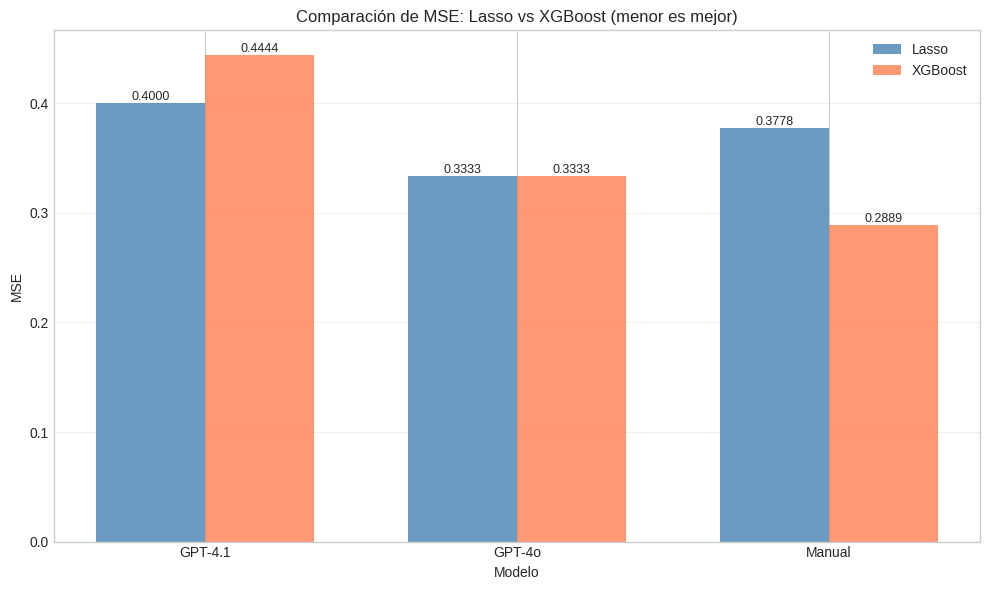

In [20]:
# Gráfico comparativo de MSE
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_comp))
ancho = 0.35

bars1 = ax.bar(x - ancho/2, df_comp['MSE_Lasso'], ancho,
               label='Lasso', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + ancho/2, df_comp['MSE_XGBoost'], ancho,
               label='XGBoost', color='coral', alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('MSE')
ax.set_title('Comparación de MSE: Lasso vs XGBoost (menor es mejor)')
ax.set_xticks(x)
ax.set_xticklabels(df_comp['Modelo'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Valores en barras
for bars in [bars1, bars2]:
    for bar in bars:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., altura,
                f'{altura:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

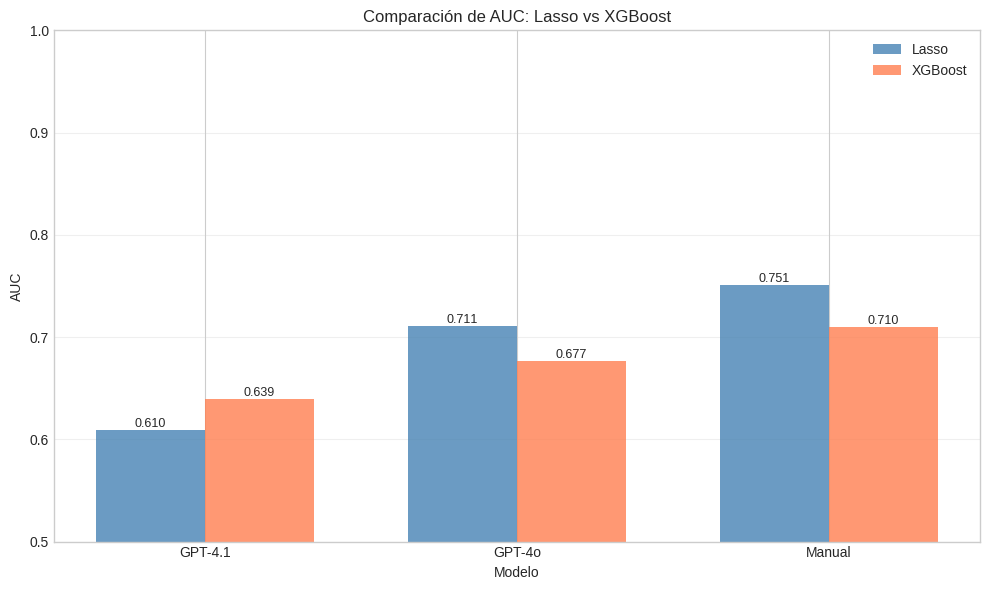

In [ ]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_comp))
ancho = 0.35

bars1 = ax.bar(x - ancho/2, df_comp['AUC_Lasso'], ancho,
               label='Lasso', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + ancho/2, df_comp['AUC_XGBoost'], ancho,
               label='XGBoost', color='coral', alpha=0.8)

ax.set_xlabel('Modelo')
ax.set_ylabel('AUC')
ax.set_title('Comparación de AUC: Lasso vs XGBoost')
ax.set_xticks(x)
ax.set_xticklabels(df_comp['Modelo'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0.5, 1.0])

# Valores en barras
for bars in [bars1, bars2]:
    for bar in bars:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., altura,
                f'{altura:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 10. Visualizaciones de rendimiento de XGBoost

#### Curvas ROC

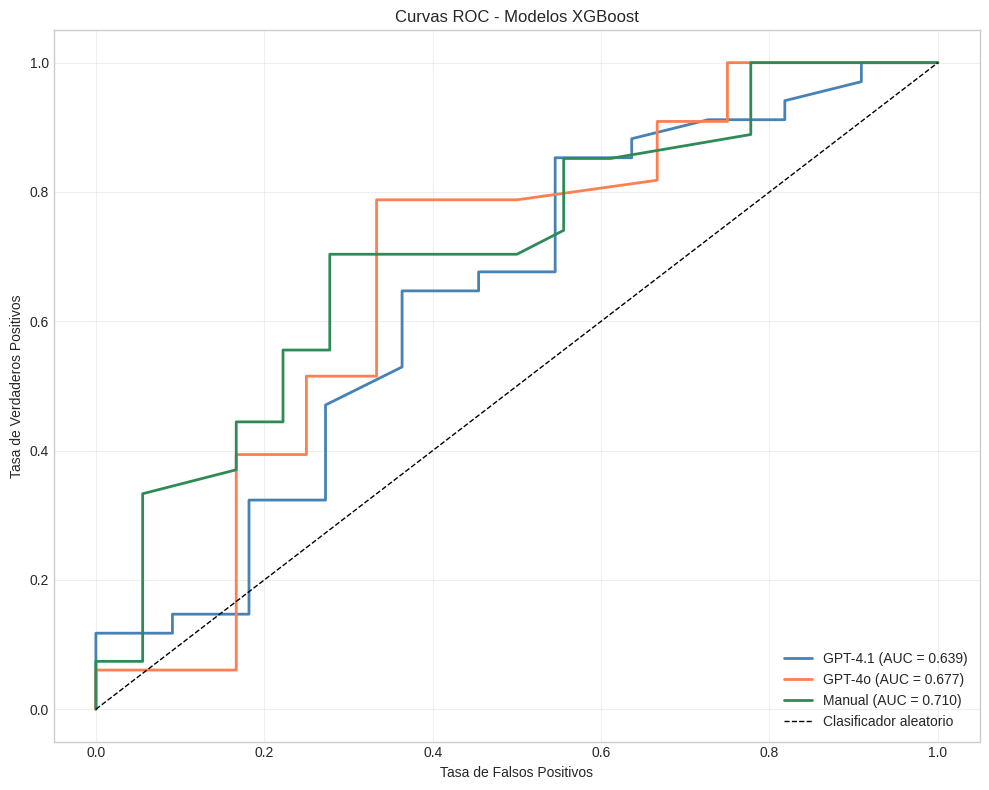

In [21]:
plt.figure(figsize=(10, 8))

colores = {'GPT-4.1': 'steelblue', 'GPT-4o': 'coral', 'Manual': 'seagreen'}

for nombre in ['GPT-4.1', 'GPT-4o', 'Manual']:
    fpr = resultados_xgb[nombre]['fpr']
    tpr = resultados_xgb[nombre]['tpr']
    auc = resultados_xgb[nombre]['metricas']['auc']

    plt.plot(fpr, tpr, linewidth=2,
             label=f'{nombre} (AUC = {auc:.3f})',
             color=colores[nombre])

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC - Modelos XGBoost')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Matrices de confusión

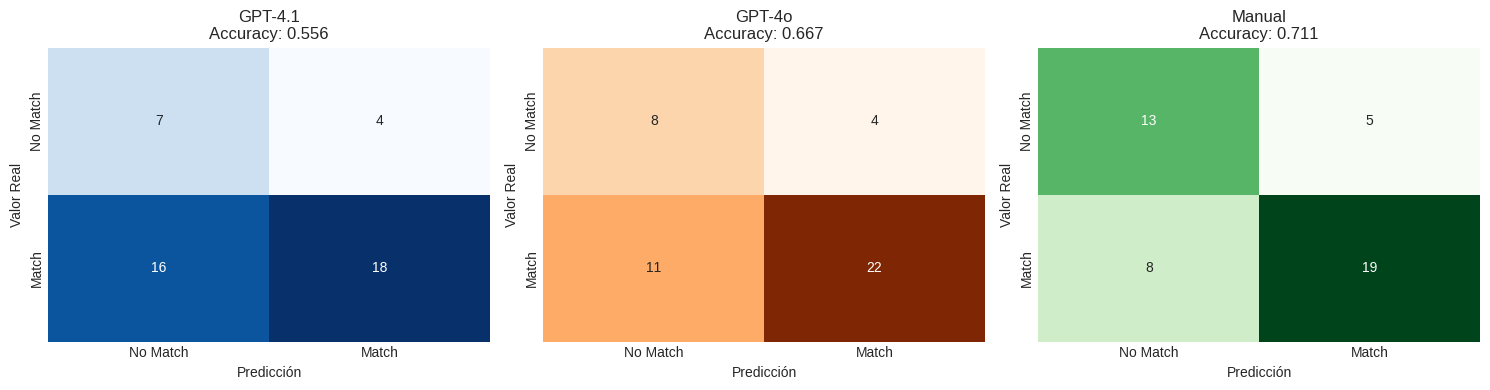

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cmaps = {'GPT-4.1': 'Blues', 'GPT-4o': 'Oranges', 'Manual': 'Greens'}

for idx, nombre in enumerate(['GPT-4.1', 'GPT-4o', 'Manual']):
    cm = resultados_xgb[nombre]['cm']
    acc = resultados_xgb[nombre]['metricas']['accuracy']

    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[nombre],
                ax=axes[idx], cbar=False,
                xticklabels=['No Match', 'Match'],
                yticklabels=['No Match', 'Match'])

    axes[idx].set_title(f'{nombre}\nAccuracy: {acc:.3f}')
    axes[idx].set_ylabel('Valor Real')
    axes[idx].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

#### Feature Importance de XGBoost

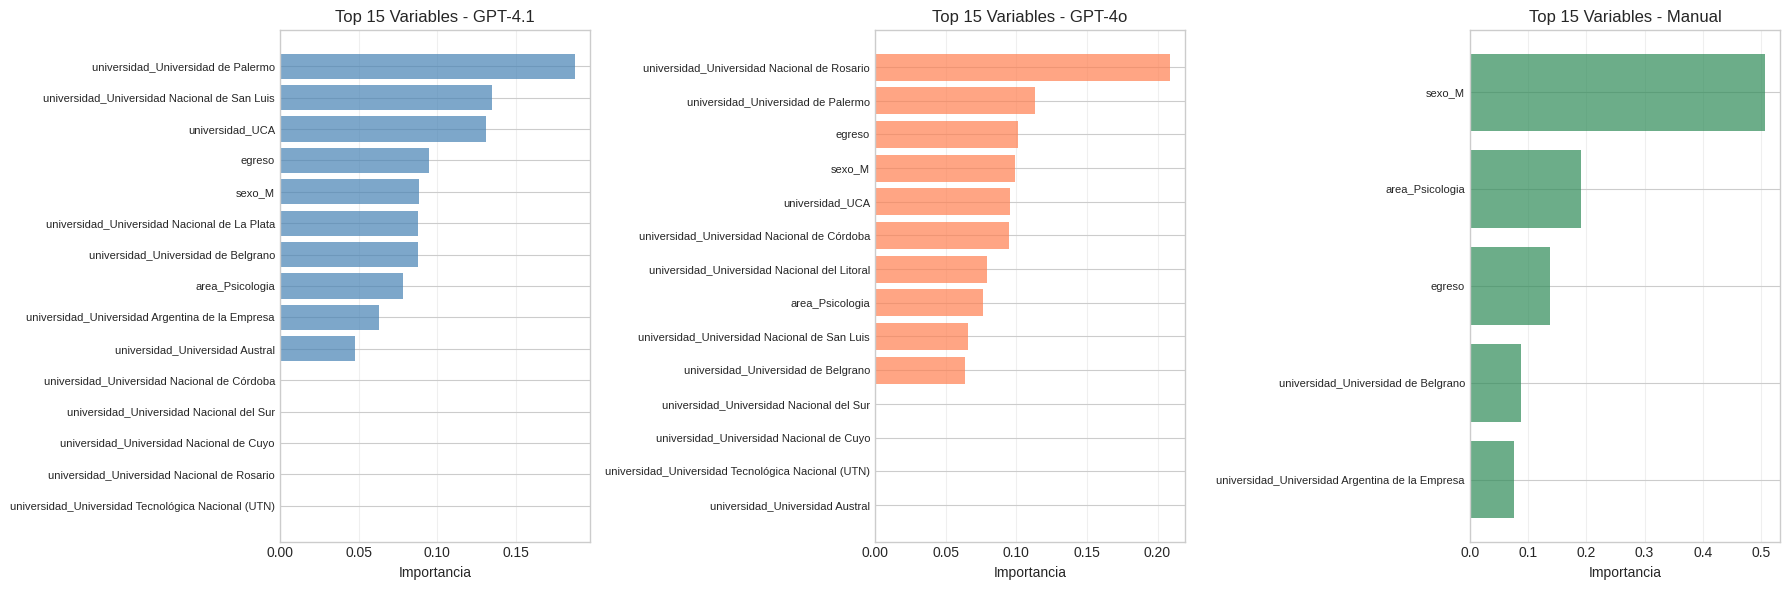

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, nombre in enumerate(['GPT-4.1', 'GPT-4o', 'Manual']):
    imp = resultados_xgb[nombre]['importancia'].head(15)

    axes[idx].barh(range(len(imp)), imp['Importancia'],
                   color=colores[nombre], alpha=0.7)
    axes[idx].set_yticks(range(len(imp)))
    axes[idx].set_yticklabels(imp['Variable'], fontsize=8)
    axes[idx].set_title(f'Top 15 Variables - {nombre}')
    axes[idx].set_xlabel('Importancia')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

### 11. Análisis predictivo: Probabilidades por Universidad y Área

Usando cada modelo

### Manual


In [26]:
# Usar modelo Manual
modelo_ref = resultados_xgb['Manual']['modelo']
vars_modelo = resultados_lasso['Manual']['variables_seleccionadas']
importancia_xgb = resultados_xgb['Manual']['importancia']  # o el que uses

# Obtener universidades con importancia > 0
universidades_importantes = []
for var in importancia_xgb[importancia_xgb['Importancia'] > 0]['Variable']:
    if var.startswith('universidad_'):
        univ_nombre = var.replace('universidad_', '')
        universidades_importantes.append(univ_nombre)

# Usar solo esas universidades
if len(universidades_importantes) > 0:
    universidades = universidades_importantes
    print(f'\nUniversidades con importancia > 0 en XGBoost: {len(universidades)}')
    print('Universidades incluidas en predicciones:')
    for u in universidades:
        # Buscar la importancia
        var_u = f'universidad_{u}'
        imp_val = importancia_xgb[importancia_xgb['Variable'] == var_u]['Importancia'].values
        if len(imp_val) > 0:
            print(f'  - {u}: importancia = {imp_val[0]:.4f}')
else:
    print('\nAdvertencia: Ninguna universidad tiene importancia > 0')
    universidades = []


Universidades con importancia > 0 en XGBoost: 2
Universidades incluidas en predicciones:
  - Universidad de Belgrano: importancia = 0.0886
  - Universidad Argentina de la Empresa: importancia = 0.0766


In [27]:
# Generar predicciones para todas las combinaciones
predicciones = []

for univ in universidades:
    for area in areas:
        # Crear instancia con todas las columnas de X
        instancia = pd.DataFrame(columns=X[vars_modelo].columns, index=[0])
        instancia.fillna(0, inplace=True)

        # Asignar egreso
        if 'egreso' in instancia.columns:
            instancia['egreso'] = egreso_ref

        # Activar dummies correspondientes
        for col in X[vars_modelo].columns:
            if col.startswith('universidad_') and univ in col:
                instancia[col] = 1
            elif col.startswith('area_') and area in col:
                instancia[col] = 1

        # Usar solo variables del modelo
        instancia_modelo = instancia[vars_modelo]


        # Predicción
        prob = modelo_ref.predict_proba(instancia_modelo)[0, 1]

        predicciones.append({
            'Universidad': univ,
            'Area': area,
            'Prob_Match': prob,
            'Prob_Match_Pct': prob * 100
        })

df_pred = pd.DataFrame(predicciones).sort_values('Prob_Match', ascending=False)

print('\n' + '='*70)
print('Top 10: Combinaciones con mayor probabilidad de match')
print('='*70)
print(df_pred.head(10)[['Universidad', 'Area', 'Prob_Match_Pct']].to_string(index=False))

print('\n' + '='*70)
print('Bottom 10: Combinaciones con menor probabilidad de match')
print('='*70)
print(df_pred.tail(10)[['Universidad', 'Area', 'Prob_Match_Pct']].to_string(index=False))

NameError: name 'areas' is not defined

In [28]:
# Estadísticas por área
print('='*70)
print('Estadísticas por área')
print('='*70)
stats = df_pred.groupby('Area')['Prob_Match_Pct'].agg(['mean', 'std', 'min', 'max']).round(2)
stats.columns = ['Media', 'Desv_Est', 'Mínimo', 'Máximo']
print(stats)

# Top universidades
print('\n' + '='*70)
print('Top 5 universidades (probabilidad promedio de match)')
print('='*70)
top_univ = df_pred.groupby('Universidad')['Prob_Match_Pct'].mean().sort_values(ascending=False).head(5)
print(top_univ.round(2).to_string())

Estadísticas por área


NameError: name 'df_pred' is not defined

#### Heatmap de probabilidades

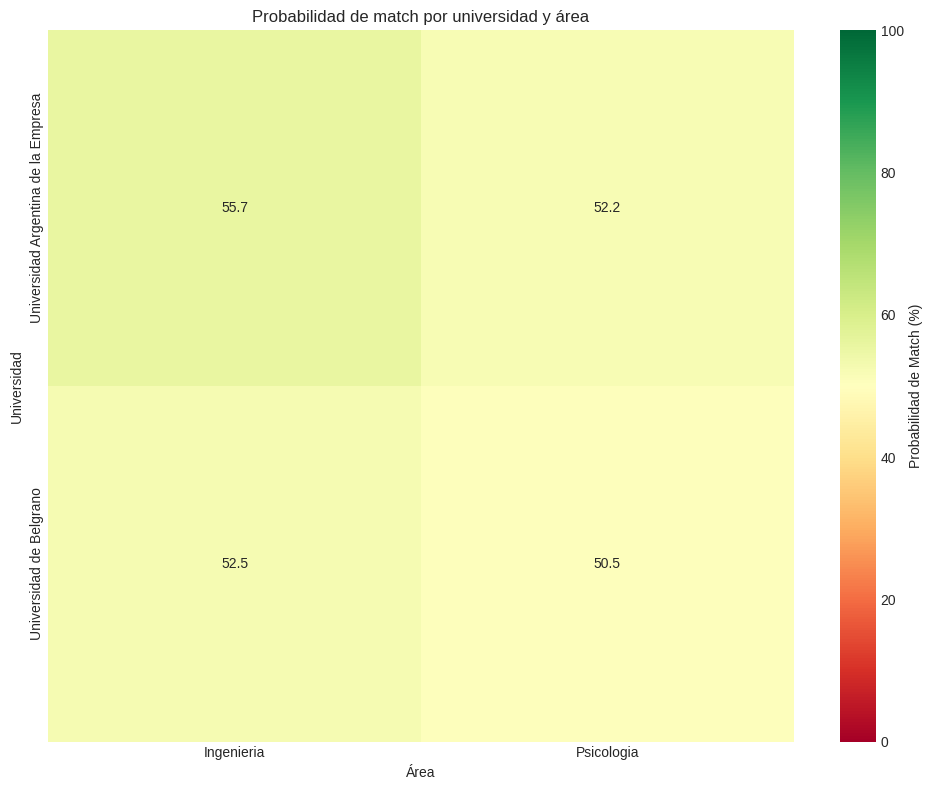

In [ ]:
tabla_pivot = df_pred.pivot_table(
    values='Prob_Match_Pct',
    index='Universidad',
    columns='Area'
)

plt.figure(figsize=(10, max(8, len(universidades) * 0.4)))
sns.heatmap(tabla_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Probabilidad de Match (%)'},
            vmin=0, vmax=100)
plt.title('Probabilidad de match por universidad y área')
plt.xlabel('Área')
plt.ylabel('Universidad')
plt.tight_layout()
plt.show()

### GPT-4o


In [ ]:
# Usar modelo Manual
modelo_ref = resultados_xgb['GPT-4o']['modelo']
vars_modelo = resultados_lasso['GPT-4o']['variables_seleccionadas']
importancia_xgb = resultados_xgb['GPT-4o']['importancia']  # o el que uses

# Obtener universidades con importancia > 0
universidades_importantes = []
for var in importancia_xgb[importancia_xgb['Importancia'] > 0]['Variable']:
    if var.startswith('universidad_'):
        univ_nombre = var.replace('universidad_', '')
        universidades_importantes.append(univ_nombre)

# Usar solo esas universidades
if len(universidades_importantes) > 0:
    universidades = universidades_importantes
    print(f'\nUniversidades con importancia > 0 en XGBoost: {len(universidades)}')
    print('Universidades incluidas en predicciones:')
    for u in universidades:
        # Buscar la importancia
        var_u = f'universidad_{u}'
        imp_val = importancia_xgb[importancia_xgb['Variable'] == var_u]['Importancia'].values
        if len(imp_val) > 0:
            print(f'  - {u}: importancia = {imp_val[0]:.4f}')
else:
    print('\nAdvertencia: Ninguna universidad tiene importancia > 0')
    universidades = []


Universidades con importancia > 0 en XGBoost: 7
Universidades incluidas en predicciones:
  - Universidad Nacional de Rosario: importancia = 0.2090
  - Universidad de Palermo: importancia = 0.1131
  - UCA: importancia = 0.0959
  - Universidad Nacional de Córdoba: importancia = 0.0952
  - Universidad Nacional del Litoral: importancia = 0.0794
  - Universidad Nacional de San Luis: importancia = 0.0660
  - Universidad de Belgrano: importancia = 0.0637


In [ ]:
# Generar predicciones para todas las combinaciones
predicciones = []

for univ in universidades:
    for area in areas:
        # Crear instancia con todas las columnas de X
        instancia = pd.DataFrame(columns=X[vars_modelo].columns, index=[0])
        instancia.fillna(0, inplace=True)

        # Asignar egreso
        if 'egreso' in instancia.columns:
            instancia['egreso'] = egreso_ref

        # Activar dummies correspondientes
        for col in X[vars_modelo].columns:
            if col.startswith('universidad_') and univ in col:
                instancia[col] = 1
            elif col.startswith('area_') and area in col:
                instancia[col] = 1

        # Usar solo variables del modelo
        instancia_modelo = instancia[vars_modelo]


        # Predicción
        prob = modelo_ref.predict_proba(instancia_modelo)[0, 1]

        predicciones.append({
            'Universidad': univ,
            'Area': area,
            'Prob_Match': prob,
            'Prob_Match_Pct': prob * 100
        })

df_pred = pd.DataFrame(predicciones).sort_values('Prob_Match', ascending=False)

print('\n' + '='*70)
print('Combinaciones con mayor probabilidad de match')
print('='*70)
print(df_pred[['Universidad', 'Area', 'Prob_Match_Pct']].to_string(index=False))




Combinaciones con mayor probabilidad de match
                     Universidad       Area  Prob_Match_Pct
 Universidad Nacional de Córdoba Ingenieria       77.230042
 Universidad Nacional de Rosario Ingenieria       76.348442
 Universidad Nacional de Rosario Psicologia       72.144501
 Universidad Nacional de Córdoba Psicologia       70.577942
Universidad Nacional del Litoral Ingenieria       59.247746
         Universidad de Belgrano Ingenieria       54.576187
Universidad Nacional del Litoral Psicologia       53.527321
Universidad Nacional de San Luis Ingenieria       47.058189
         Universidad de Belgrano Psicologia       46.858696
          Universidad de Palermo Ingenieria       46.490891
Universidad Nacional de San Luis Psicologia       41.346004
                             UCA Ingenieria       39.308941
          Universidad de Palermo Psicologia       35.807613
                             UCA Psicologia       30.917677


In [ ]:
# Estadísticas por área
print('='*70)
print('Estadísticas por área')
print('='*70)
stats = df_pred.groupby('Area')['Prob_Match_Pct'].agg(['mean', 'std', 'min', 'max']).round(2)
stats.columns = ['Media', 'Desv_Est', 'Mínimo', 'Máximo']
print(stats)

# Top universidades
print('\n' + '='*70)
print('Top 5 universidades (probabilidad promedio de match)')
print('='*70)
top_univ = df_pred.groupby('Universidad')['Prob_Match_Pct'].mean().sort_values(ascending=False).head(5)
print(top_univ.round(2).to_string())

Estadísticas por área
                Media   Desv_Est     Mínimo     Máximo
Area                                                  
Ingenieria  57.180000  14.810000  39.310001  77.230003
Psicologia  50.169998  16.209999  30.920000  72.139999

Top 5 universidades (probabilidad promedio de match)
Universidad
Universidad Nacional de Rosario     74.250000
Universidad Nacional de Córdoba     73.900002
Universidad Nacional del Litoral    56.389999
Universidad de Belgrano             50.720001
Universidad Nacional de San Luis    44.200001


#### Heatmap de probabilidades

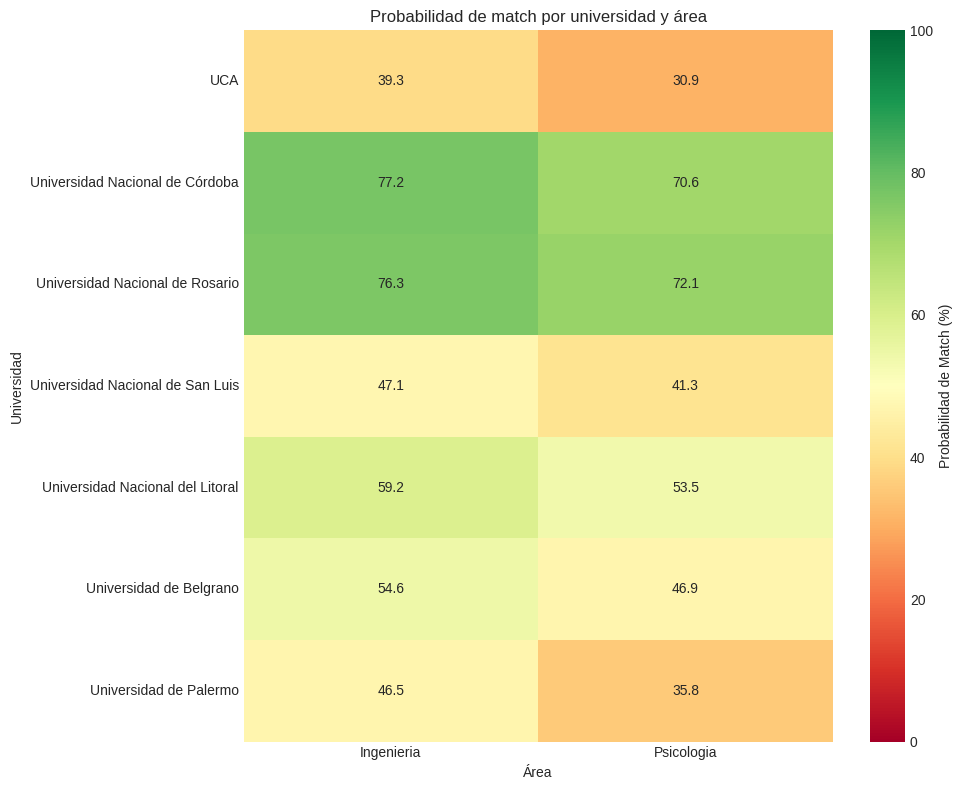

In [ ]:
tabla_pivot = df_pred.pivot_table(
    values='Prob_Match_Pct',
    index='Universidad',
    columns='Area'
)

plt.figure(figsize=(10, max(8, len(universidades) * 0.4)))
sns.heatmap(tabla_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Probabilidad de Match (%)'},
            vmin=0, vmax=100)
plt.title('Probabilidad de match por universidad y área')
plt.xlabel('Área')
plt.ylabel('Universidad')
plt.tight_layout()
plt.show()

### GPT-4.1


In [ ]:
# Usar modelo Manual
modelo_ref = resultados_xgb['GPT-4.1']['modelo']
vars_modelo = resultados_lasso['GPT-4.1']['variables_seleccionadas']
importancia_xgb = resultados_xgb['GPT-4.1']['importancia']  # o el que uses

# Obtener universidades con importancia > 0
universidades_importantes = []
for var in importancia_xgb[importancia_xgb['Importancia'] > 0]['Variable']:
    if var.startswith('universidad_'):
        univ_nombre = var.replace('universidad_', '')
        universidades_importantes.append(univ_nombre)

# Usar solo esas universidades
if len(universidades_importantes) > 0:
    universidades = universidades_importantes
    print(f'\nUniversidades con importancia > 0 en XGBoost: {len(universidades)}')
    print('Universidades incluidas en predicciones:')
    for u in universidades:
        # Buscar la importancia
        var_u = f'universidad_{u}'
        imp_val = importancia_xgb[importancia_xgb['Variable'] == var_u]['Importancia'].values
        if len(imp_val) > 0:
            print(f'  - {u}: importancia = {imp_val[0]:.4f}')
else:
    print('\nAdvertencia: Ninguna universidad tiene importancia > 0')
    universidades = []


Universidades con importancia > 0 en XGBoost: 7
Universidades incluidas en predicciones:
  - Universidad de Palermo: importancia = 0.1875
  - Universidad Nacional de San Luis: importancia = 0.1348
  - UCA: importancia = 0.1311
  - Universidad Nacional de La Plata: importancia = 0.0878
  - Universidad de Belgrano: importancia = 0.0876
  - Universidad Argentina de la Empresa: importancia = 0.0628
  - Universidad Austral: importancia = 0.0475


In [ ]:
# Generar predicciones para todas las combinaciones
predicciones = []

for univ in universidades:
    for area in areas:
        # Crear instancia con todas las columnas de X
        instancia = pd.DataFrame(columns=X[vars_modelo].columns, index=[0])
        instancia.fillna(0, inplace=True)

        # Asignar egreso
        if 'egreso' in instancia.columns:
            instancia['egreso'] = egreso_ref

        # Activar dummies correspondientes
        for col in X[vars_modelo].columns:
            if col.startswith('universidad_') and univ in col:
                instancia[col] = 1
            elif col.startswith('area_') and area in col:
                instancia[col] = 1

        # Usar solo variables del modelo
        instancia_modelo = instancia[vars_modelo]


        # Predicción
        prob = modelo_ref.predict_proba(instancia_modelo)[0, 1]

        predicciones.append({
            'Universidad': univ,
            'Area': area,
            'Prob_Match': prob,
            'Prob_Match_Pct': prob * 100
        })

df_pred = pd.DataFrame(predicciones).sort_values('Prob_Match', ascending=False)

print('\n' + '='*70)
print('Combinaciones con mayor probabilidad de match')
print('='*70)
print(df_pred[['Universidad', 'Area', 'Prob_Match_Pct']].to_string(index=False))




Combinaciones con mayor probabilidad de match
                        Universidad       Area  Prob_Match_Pct
Universidad Argentina de la Empresa Psicologia       75.349373
   Universidad Nacional de La Plata Psicologia       75.122757
                Universidad Austral Psicologia       72.921028
Universidad Argentina de la Empresa Ingenieria       71.001556
   Universidad Nacional de La Plata Ingenieria       70.750496
                Universidad Austral Ingenieria       68.324974
                                UCA Psicologia       67.136765
            Universidad de Belgrano Psicologia       60.373169
                                UCA Ingenieria       59.261559
            Universidad de Belgrano Ingenieria       54.962742
   Universidad Nacional de San Luis Psicologia       34.682411
   Universidad Nacional de San Luis Ingenieria       27.902021
             Universidad de Palermo Ingenieria       27.777576
             Universidad de Palermo Psicologia       27.271955


In [ ]:
# Estadísticas por área
print('='*70)
print('Estadísticas por área')
print('='*70)
stats = df_pred.groupby('Area')['Prob_Match_Pct'].agg(['mean', 'std', 'min', 'max']).round(2)
stats.columns = ['Media', 'Desv_Est', 'Mínimo', 'Máximo']
print(stats)

# Top universidades
print('\n' + '='*70)
print('Top 5 universidades (probabilidad promedio de match)')
print('='*70)
top_univ = df_pred.groupby('Universidad')['Prob_Match_Pct'].mean().sort_values(ascending=False).head(5)
print(top_univ.round(2).to_string())

Estadísticas por área
                Media   Desv_Est     Mínimo     Máximo
Area                                                  
Ingenieria  54.279999  19.020000  27.780001  71.000000
Psicologia  58.980000  19.950001  27.270000  75.349998

Top 5 universidades (probabilidad promedio de match)
Universidad
Universidad Argentina de la Empresa    73.180000
Universidad Nacional de La Plata       72.940002
Universidad Austral                    70.620003
UCA                                    63.200001
Universidad de Belgrano                57.669998


#### Heatmap de probabilidades

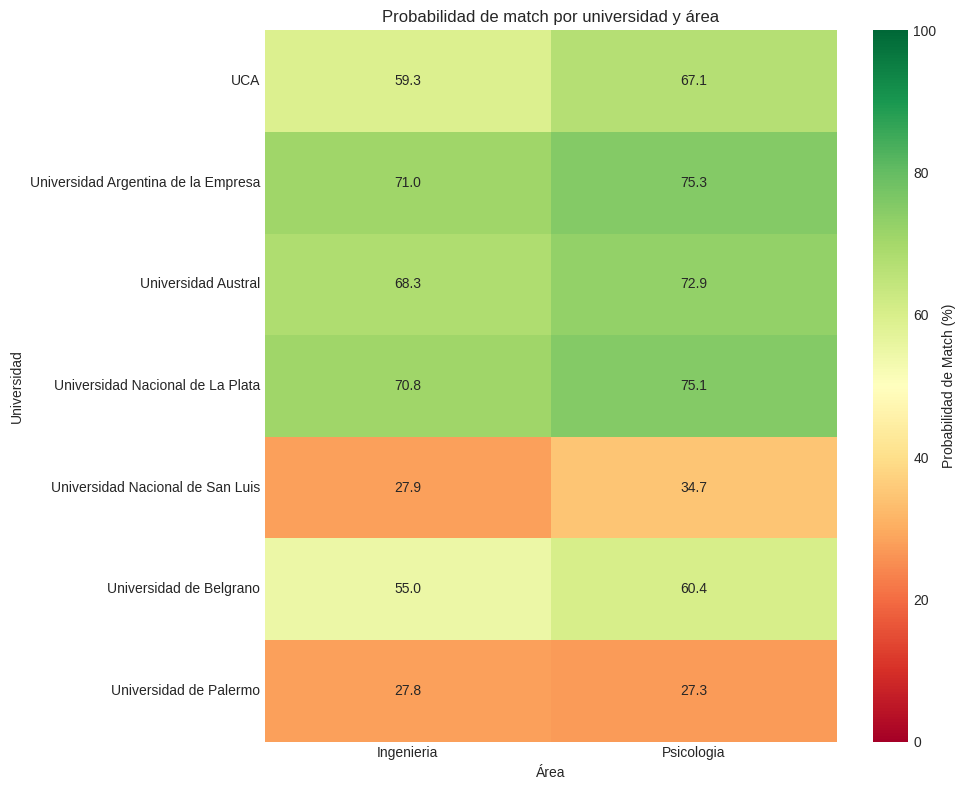

In [ ]:
tabla_pivot = df_pred.pivot_table(
    values='Prob_Match_Pct',
    index='Universidad',
    columns='Area'
)

plt.figure(figsize=(10, max(8, len(universidades) * 0.4)))
sns.heatmap(tabla_pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            cbar_kws={'label': 'Probabilidad de Match (%)'},
            vmin=0, vmax=100)
plt.title('Probabilidad de match por universidad y área')
plt.xlabel('Área')
plt.ylabel('Universidad')
plt.tight_layout()
plt.show()

### 12. Conclusiones

In [ ]:
print('='*70)
print('CONCLUSIONES DEL ANÁLISIS')
print('='*70)

print('\n1. Selección de variables con Lasso:')
print('-' * 70)

# Variables comunes
vars_comunes = set(resultados_lasso['GPT-4.1']['variables_seleccionadas'])
for nombre in ['GPT-4o', 'Manual']:
    vars_comunes &= set(resultados_lasso[nombre]['variables_seleccionadas'])

print(f'\nVariables seleccionadas en los 3 modelos: {len(vars_comunes)}')
if len(vars_comunes) > 0:
    print('Variables consistentes:')
    for var in list(vars_comunes)[:10]:
        print(f'  - {var}')

print('\n2. Rendimiento de XGBoost:')
print('-' * 70)

mejor = max(['GPT-4.1', 'GPT-4o', 'Manual'],
            key=lambda x: resultados_xgb[x]['metricas']['auc'])
mejor_auc = resultados_xgb[mejor]['metricas']['auc']

print(f'\nModelo con mejor AUC: {mejor} ({mejor_auc:.4f})')
print(f'Accuracy: {resultados_xgb[mejor]["metricas"]["accuracy"]:.4f}')
print(f'F1-Score: {resultados_xgb[mejor]["metricas"]["f1"]:.4f}')

mejora = df_comp['Mejora_AUC_pp'].mean()
print(f'\nMejora promedio de XGBoost sobre Lasso: {mejora:.2f} p.p.')

if mejor_auc > 0.75:
    print('\nEl modelo tiene excelente capacidad predictiva (AUC > 0.75)')
elif mejor_auc > 0.70:
    print('\nEl modelo tiene buena capacidad predictiva (AUC > 0.70)')
else:
    print('\nCapacidad predictiva moderada, considerar más variables')

print('\n3. Análisis Universidad-Área:')
print('-' * 70)

mejor_combo = df_pred.iloc[0]
peor_combo = df_pred.iloc[-1]

print(f'\nMejor combinación:')
print(f'  {mejor_combo["Universidad"]} + {mejor_combo["Area"]}')
print(f'  Probabilidad: {mejor_combo["Prob_Match_Pct"]:.1f}%')

print(f'\nPeor combinación:')
print(f'  {peor_combo["Universidad"]} + {peor_combo["Area"]}')
print(f'  Probabilidad: {peor_combo["Prob_Match_Pct"]:.1f}%')

print('\n' + '='*70)
print('FIN DEL ANÁLISIS')
print('='*70)

CONCLUSIONES DEL ANÁLISIS

1. Selección de variables con Lasso:
----------------------------------------------------------------------

Variables seleccionadas en los 3 modelos: 4
Variables consistentes:
  - sexo_M
  - area_Psicologia
  - egreso
  - universidad_Universidad de Belgrano

2. Rendimiento de XGBoost:
----------------------------------------------------------------------

Modelo con mejor AUC: Manual (0.7099)
Accuracy: 0.7111
F1-Score: 0.7451

Mejora promedio de XGBoost sobre Lasso: -1.53 p.p.

El modelo tiene buena capacidad predictiva (AUC > 0.70)

3. Análisis Universidad-Área:
----------------------------------------------------------------------

Mejor combinación:
  Universidad Argentina de la Empresa + Psicologia
  Probabilidad: 75.3%

Peor combinación:
  Universidad de Palermo + Psicologia
  Probabilidad: 27.3%

FIN DEL ANÁLISIS


### 13. Guardar modelos y predicciones

In [ ]:
import pickle
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M')

# Guardar modelos
for nombre in ['GPT-4.1', 'GPT-4o', 'Manual']:
    nombre_arch = nombre.replace('.', '').replace('-', '').lower()

    # XGBoost
    archivo = f'xgboost_{nombre_arch}_{timestamp}.pkl'
    with open(archivo, 'wb') as f:
        pickle.dump({
            'modelo': resultados_xgb[nombre]['modelo'],
            'variables': resultados_lasso[nombre]['variables_seleccionadas'],
            'metricas': resultados_xgb[nombre]['metricas']
        }, f)

    print(f'Modelo guardado: {archivo}')

# Guardar predicciones
archivo_pred = f'predicciones_{timestamp}.csv'
df_pred.to_csv(archivo_pred, index=False)
print(f'\nPredicciones guardadas: {archivo_pred}')

print('\nProceso completado exitosamente')

Modelo guardado: xgboost_gpt41_20260213_2242.pkl
Modelo guardado: xgboost_gpt4o_20260213_2242.pkl
Modelo guardado: xgboost_manual_20260213_2242.pkl

Predicciones guardadas: predicciones_20260213_2242.csv

Proceso completado exitosamente


#Adicional: Removiendo egreso y sexo como parametros

In [ ]:
# # Definir X (variables independientes) e Y (variables dependientes)

# # Excluir variables que no son predictores
# columnas_excluir = ['carrera', 'match(gpt41)', 'match(gpt4o)', 'Manual','primer_trabajo','sexo','egreso']
# columnas_features = [col for col in df_encoded.columns if col not in columnas_excluir]

# X = df_encoded[columnas_features]

# # Variables objetivo
# y_gpt41 = df_encoded['match(gpt41)']
# y_gpt4o = df_encoded['match(gpt4o)']
# y_manual = df_encoded['Manual']